# Node-Count Benchmark: Naive / Bootstrap / RSBS on Real Microbiome Data

This notebook reproduces the node-count benchmark used to decide which
real synthetic-microbial-community (SynCom) node count to prioritize for
ground-truth validation (Ishizawa p=7, OMM12/Venturelli p=12, Ho p=15),
and the follow-up check on whether giving Bootstrap/RSBS more bootstrap
replicates changes their relative performance.

**This notebook uses our own `causal_comparator` package, not a
reimplementation.** It imports directly from the installed package
(`src/causal_comparator/` in the repo, installed editable via
`pyproject.toml` -- that's what the `.venv` and `causal_comparator.egg-info`
in the project folder are for):

- `causal_comparator.discovery` -- `CausalComparator`, wrapping real
  `lingam.DirectLiNGAM` for the Naive / Bootstrap / RSBS estimators.
- `causal_comparator.metrics` -- `evaluate_binary_classification`,
  `calculate_node_scores`.
- `causal_comparator.utils` -- `SHD_vectorized`, `align_matrix`.
- `causal_comparator.data_generation` -- `BaseSimulator`,
  `EdgePerturbationSimulator`, `MechanismPerturbationSimulator`
  (fully-synthetic graph generators).
- `causal_comparator.plotting` -- Plotly figure helpers
  (`plot_summary_performance`, etc.).

The **only** custom code in this notebook is the real-data-grounded
perturbation injection in Section 2 below. `causal_comparator.data_generation`'s
simulators build a synthetic baseline graph from scratch (`edge_prob`);
this project instead needs to perturb a baseline that's already been
fit to *real* Healthy-cohort data, which nothing in the package does.
Everything else -- fitting, estimating, scoring -- calls straight into
the package above.

**This notebook does not need to live inside the repo.** As long as your
`.venv` (or whichever environment has `causal_comparator` installed) is
the active kernel, `import causal_comparator` resolves via the package's
install metadata (the `.egg-info`), not via file proximity -- so this
notebook can sit in `data/Raw_Data/` (or anywhere else) and still import
it correctly. If you get a `ModuleNotFoundError`, it just means the
notebook's kernel isn't pointed at the `.venv` that has it installed.

**What it does, end to end:**
1. Loads the real, MMUPHin batch-corrected Healthy-cohort family-level CLR
   data (`healthy_family_batchcorrected_clr.csv`, 6,871 samples x 24 families).
2. For a chosen node count `p`, keeps the `p` most abundant real families
   and fits a real `lingam.DirectLiNGAM` baseline on that subset.
3. Injects a *known* node-level mechanism perturbation into that baseline
   (custom code -- Section 2; ground-truth caveat discussed there).
4. Simulates two datasets from bootstrapped real residuals and scores
   `CausalComparator`'s Naive / Bootstrap / RSBS estimators against the
   known perturbed-node labels via `causal_comparator.metrics`.
5. Repeats across node counts and perturbation loads, and builds the two
   summary charts used in the results write-up.

**Requirements to run locally:**
- The `causal_comparator` package installed in your active environment
  (already the case in the project `.venv` -- `pip install -e .` from the
  repo root if you're running this from a different environment).
- `healthy_family_batchcorrected_clr.csv` in the same directory as this
  notebook (delivered alongside it).

**A note on the numbers.** The exploratory runs behind the results
write-up were produced in a network-isolated sandbox that couldn't
`pip install lingam`, so that work used a from-scratch numpy
reimplementation instead of this library. This notebook uses the real
`causal_comparator.discovery`/`causal_comparator.metrics` throughout, so expect the exact numbers to
shift slightly from the write-up's -- the qualitative pattern across node
counts is what matters, and re-running this notebook is how you get
numbers you can actually stand behind in the results section.

**A note on runtime:** the numbers reported in the write-up used 15
repeats per (node count, perturbation-load) setting for the main grid,
and up to 90-105 bootstrap replicates for the high-n_boot check. Running
locally you have no execution-time cap, so this notebook uses smaller
defaults (fast enough to run interactively) with clear comments on where
to bump the numbers back up to match the paper.


In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lingam
from scipy import stats

from causal_comparator.discovery import CausalComparator
from causal_comparator.metrics import evaluate_binary_classification, calculate_node_scores
from causal_comparator.utils import align_matrix, SHD_vectorized

np.set_printoptions(suppress=True)
plt.rcParams["font.family"] = "DejaVu Sans"


## 1. Loading the real cohort and fitting the real baseline

Data source: MMUPHin batch-corrected Healthy cohort, family-level CLR
(`healthy_family_batchcorrected_clr.csv`, N=6,871 samples x 24 families).

For a target node count `p`, `get_subset_columns` keeps the `p` most
abundant real families (by mean CLR value) -- a fixed, reproducible,
real-data-driven choice rather than an arbitrary random subset.
`get_or_fit_baseline` fits (and caches to disk) a real `lingam.DirectLiNGAM`
baseline on that subset -- this is the same fit `CausalComparator._fit_base`
does internally for one dataset; here we just need to hold onto the
resulting `(order, adjacency_matrix)` and residuals so Section 2 can
perturb them.


In [ ]:
DATA_PATH = "./real_data_exp/healthy_family_batchcorrected_clr.csv"
CACHE_DIR = "nb_baseline_cache_v3"


def get_family_columns(data_path=DATA_PATH):
    df_full = pd.read_csv(data_path, index_col=0, nrows=1)
    return [c for c in df_full.columns if c.startswith("f__")]


def get_modeling_pool(data_path=DATA_PATH):
    """Family columns ranked by mean CLR value, with the single highest
    dropped -- removes the CLR sum-to-zero singularity (same fix applied to
    the full composition's CLR coordinates sum to exactly
    zero per sample, so the full set is linearly dependent; dropping the top
    family leaves a well-posed set for DirectLiNGAM)."""
    fam_cols = get_family_columns(data_path)
    df_full = pd.read_csv(data_path, usecols=fam_cols)
    means = df_full.mean(axis=0).sort_values(ascending=False)
    dropped = means.index[0]
    return list(means.index[1:]), dropped


def get_subset_columns(p, data_path=DATA_PATH):
    pool, dropped = get_modeling_pool(data_path)
    if p > len(pool):
        raise ValueError(f"p={p} exceeds available families after dropping "
                          f"'{dropped}' ({len(pool)})")
    return pool[:p]


def get_or_fit_baseline(p, data_path=DATA_PATH, cache_dir=CACHE_DIR):
    """Fit (or load a cached) real DirectLiNGAM baseline on the p most
    abundant real families. Returns (order, B_real, residuals, cols)."""
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = f"{cache_dir}/p{p}_baseline.npz"
    if os.path.exists(cache_path) and os.path.getsize(cache_path) > 0:
        d = np.load(cache_path, allow_pickle=True)
        return list(d["order"]), d["B_real"], d["residuals"], list(d["cols"])
    cols = get_subset_columns(p, data_path)
    df = pd.read_csv(data_path, usecols=cols)[cols]
    model = lingam.DirectLiNGAM()
    model.fit(df)
    order = list(model.causal_order_)
    B_real = model.adjacency_matrix_
    residuals = df.values - df.values @ B_real.T
    np.savez(cache_path, order=np.array(order), B_real=B_real, residuals=residuals,
             cols=np.array(cols))
    return order, B_real, residuals, cols


## 2. Real-data-grounded perturbation injection (the one custom part)

**What "ground truth" means here, precisely** (important -- see the fuller
discussion in the results write-up): this is *not* real experimental
ground truth from a wet-lab SynCom dataset. It is self-constructed:

1. Take the real `B_real` fitted in Section 1.
2. Pick a random subset of nodes and edit their parent sets in `B_real`
   (remove some real edges, add new ones drawn from the empirical
   distribution of real edge weights) to build `B_pert`. The identity of
   the changed nodes (`T`) is known because we made the change ourselves.
3. Simulate two new datasets from `B_real` and `B_pert` using bootstrapped
   *real* residuals (not synthetic Gaussian/Laplace noise) -- this keeps
   the marginal noise realistic while the causal structure is exactly
   controlled.

This is why it's custom: `causal_comparator.data_generation`'s
`MechanismPerturbationSimulator` does the same *kind* of edit (swap
`n_positives` parents in/out of target nodes) but builds its own random
`B1` from scratch via `edge_prob` -- it has no way to start from a
baseline that was fit to real data. The edit logic below is deliberately
close to `MechanismPerturbationSimulator.create_graphs` for consistency
with the rest of the project, just applied to `B_real` instead of a
fresh random graph.


In [40]:
N_POS = 4  # number of parent edges changed per perturbed target node


def perturb_graph(B_real, order, rng, n_pert, n_pos=N_POS):
    """Pick n_pert target nodes and, for each, remove up to n_pos existing
    parent edges and add up to n_pos new ones (drawn from the empirical
    distribution of real |edge weight| magnitudes). Returns (B_pert, T)."""
    p = B_real.shape[0]
    pos_of = {node: i for i, node in enumerate(order)}
    eligible_targets = [k for k in range(p) if pos_of[k] >= n_pos]
    T = rng.choice(eligible_targets, size=min(n_pert, len(eligible_targets)), replace=False)
    nonzero_vals = B_real[np.abs(B_real) > 1e-8]
    B_pert = B_real.copy()
    for k in T:
        preds_all = [j for j in order[:pos_of[k]]]
        current_parents = [j for j in preds_all if abs(B_real[k, j]) > 1e-8]
        non_parents = [j for j in preds_all if abs(B_real[k, j]) <= 1e-8]
        n_remove = min(n_pos, len(current_parents))
        n_add = min(n_pos, len(non_parents))
        if n_remove > 0:
            to_remove = rng.choice(current_parents, size=n_remove, replace=False)
            for j in to_remove:
                B_pert[k, j] = 0.0
        if n_add > 0:
            to_add = rng.choice(non_parents, size=n_add, replace=False)
            for j in to_add:
                mag = rng.choice(np.abs(nonzero_vals)) if len(nonzero_vals) else 0.5
                sign = rng.choice([-1, 1])
                B_pert[k, j] = sign * mag
    return B_pert, np.array(sorted(T))


def simulate_from_B(B, order, residual_pool, n_samples, rng):
    """Simulate n_samples draws from the linear SEM implied by B, using
    bootstrap-resampled rows of residual_pool as the noise term."""
    p = B.shape[0]
    idx = rng.integers(0, residual_pool.shape[0], size=n_samples)
    e = residual_pool[idx]
    I = np.eye(p)
    X = (np.linalg.inv(I - B) @ e.T).T
    return X


## 3. Running one experiment setting via `CausalComparator` + `causal_comparator.metrics`

`run_one_setting(p, n_pert, rep, n_boot, N1, N2)` ties Sections 1-2 to the
library: perturb the real baseline, simulate two datasets, wrap them as
`pd.DataFrame`s with the real family names as columns (required by
`CausalComparator._validate_data`), then call straight into
`discovery.CausalComparator` for all three estimators and
`metrics.calculate_node_scores` / `metrics.evaluate_binary_classification`
for scoring. No estimator or metric logic is reimplemented here.

`CausalComparator`'s Naive/Bootstrap paths don't take an explicit `seed`
argument (only `estimate_rsbs` does, for its downsampling step), so
`np.random.seed(...)` is set before each call to get run-to-run
reproducibility from the shared global NumPy random state.

The seed formula (`90000 + p*1000 + n_pert*100 + rep`) matches the one
used to produce the results in the write-up.


In [41]:
N1_DEFAULT, N2_DEFAULT = 300, 150


def run_one_setting(p, n_pert, rep, n_boot=6, N1=N1_DEFAULT, N2=N2_DEFAULT, verbose=False):
    t0 = time.time()
    order, B_real, residuals, cols = get_or_fit_baseline(p)

    seed = 90000 + p * 1000 + n_pert * 100 + rep
    rng = np.random.default_rng(seed)
    B_pert, T = perturb_graph(B_real, order, rng, n_pert)
    y = np.zeros(p)
    y[T] = 1

    X1 = simulate_from_B(B_real, order, residuals, N1, rng)
    X2 = simulate_from_B(B_pert, order, residuals, N2, rng)
    df1 = pd.DataFrame(X1, columns=cols)
    df2 = pd.DataFrame(X2, columns=cols)

    est_seed = seed + 1000
    cc = CausalComparator(df1, df2)

    np.random.seed(est_seed)
    delta_naive = cc.estimate_naive()
    np.random.seed(est_seed + 1)
    delta_boot = cc.estimate_bootstrap(n_sampling=n_boot)
    delta_rsbs = cc.estimate_rsbs(n_sampling=n_boot, seed=est_seed + 2)

    deltas = {"naive": delta_naive, "bootstrap": delta_boot, "rsbs": delta_rsbs}
    rows = []
    for method, delta in deltas.items():
        s = calculate_node_scores(delta, mode="incoming")
        res = evaluate_binary_classification(y, s)
        res.update({"p": p, "n_pert": n_pert, "pct": round(100 * n_pert / p, 1),
                     "rep": rep, "method": method, "n_boot": n_boot})
        rows.append(res)
    if verbose:
        print(f"p={p} n_pert={n_pert} rep={rep}: T={T.tolist()}, {time.time()-t0:.1f}s")
    return rows


## 4. Running the full node-count grid

The grid used in the write-up: `p in {7, 12, 15, 20}`, with 1-3
perturbation-load settings per `p`, 15 repeats each, `n_boot=6`.

`N_REPS` below defaults to a small number so this cell runs in a couple of
minutes on a laptop. **Set `N_REPS = 15` to reproduce the exact numbers
reported in the write-up** (this will take longer -- there is no
execution-time cap running locally, so just let it run).


In [42]:
GRID = {
   # 7:  [1, 2],
   # 12: [2, 3],
    15: [2, 3, 4],
    20: [2, 3, 4],
    23: [2, 3, 4],
}
N_REPS = 20   # set to 15 to match the numbers reported in the write-up

all_rows = []
for p, n_pert_list in GRID.items():
    for n_pert in n_pert_list:
        for rep in range(N_REPS):
            all_rows.extend(run_one_setting(p, n_pert, rep, n_boot=100, verbose=True))

results = pd.DataFrame(all_rows)
results.to_csv("nodecount_results_local.csv", index=False)
results.groupby(["p", "method"])[["auc_roc", "aupr"]].mean().round(3)


p=15 n_pert=2 rep=0: T=[4, 14], 128.4s
p=15 n_pert=2 rep=1: T=[1, 14], 126.6s
p=15 n_pert=2 rep=2: T=[2, 6], 118.5s
p=15 n_pert=2 rep=3: T=[8, 11], 122.4s
p=15 n_pert=2 rep=4: T=[8, 11], 132.3s
p=15 n_pert=2 rep=5: T=[4, 14], 125.5s
p=15 n_pert=2 rep=6: T=[5, 14], 127.2s
p=15 n_pert=2 rep=7: T=[7, 14], 127.3s
p=15 n_pert=2 rep=8: T=[0, 5], 128.4s
p=15 n_pert=2 rep=9: T=[6, 7], 113.0s
p=15 n_pert=2 rep=10: T=[1, 5], 112.5s
p=15 n_pert=2 rep=11: T=[4, 14], 111.1s
p=15 n_pert=2 rep=12: T=[1, 2], 112.4s
p=15 n_pert=2 rep=13: T=[6, 7], 112.9s
p=15 n_pert=2 rep=14: T=[5, 11], 110.8s
p=15 n_pert=2 rep=15: T=[6, 7], 112.1s
p=15 n_pert=2 rep=16: T=[4, 5], 111.8s
p=15 n_pert=2 rep=17: T=[1, 11], 113.5s
p=15 n_pert=2 rep=18: T=[2, 6], 111.7s
p=15 n_pert=2 rep=19: T=[2, 4], 114.1s
p=15 n_pert=3 rep=0: T=[6, 7, 11], 112.3s
p=15 n_pert=3 rep=1: T=[1, 2, 8], 111.5s
p=15 n_pert=3 rep=2: T=[1, 4, 14], 113.0s
p=15 n_pert=3 rep=3: T=[4, 5, 11], 111.6s
p=15 n_pert=3 rep=4: T=[4, 5, 14], 112.0s
p=15 n_pert

auc_roc   aupr
p  method                   
15 bootstrap    0.708  0.502
   naive        0.625  0.366
   rsbs         0.662  0.465
20 bootstrap    0.654  0.361
   naive        0.610  0.304
   rsbs         0.637  0.348
23 bootstrap    0.602  0.266
   naive        0.600  0.242
   rsbs         0.626  0.316

## 5. Chart 1 — AUCROC / AUPR by node count and estimator

`causal_comparator.plotting` ships `plot_summary_performance` /
`plot_ranking_metrics`, but they aggregate across all rows by `method`
only (Plotly boxplots/bars) -- they don't facet by node count `p`, which
is the whole point of this benchmark. So the chart below is custom
(matplotlib, faceted by `p`), to reproduce the exact figure used in the
write-up. If you want the package's own interactive view of the *pooled*
results (ignoring `p`), it's one line:

```python
from causal_comparator.plotting import plot_summary_performance
plot_summary_performance(results, save_path="summary.html")
```


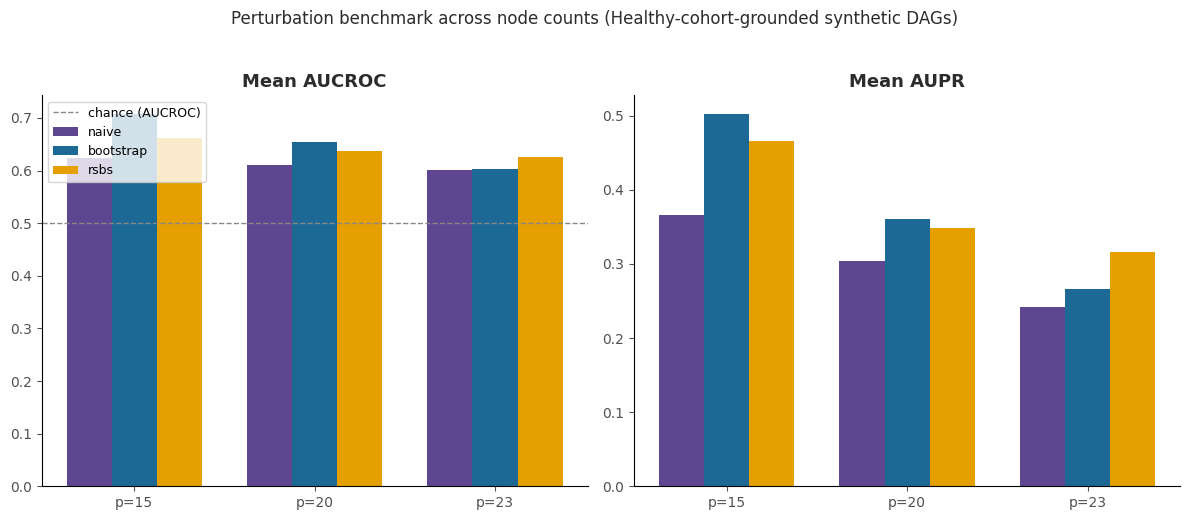

In [44]:
def make_nodecount_chart(results_df, save_path="nodecount_benchmark_local.png"):
    agg = results_df.groupby(["p", "method"])[["auc_roc", "aupr"]].mean().reset_index()
    p_vals = sorted(results_df["p"].unique())
    methods = ["naive", "bootstrap", "rsbs"]
    colors = {'naive': '#5F4690', 'bootstrap': '#1D6996', 'rsbs': '#E69F00'}
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(p_vals))
    width = 0.25
    for ax, metric, title in zip(axes, ["auc_roc", "aupr"], ["Mean AUCROC", "Mean AUPR"]):
        for i, m in enumerate(methods):
            vals = [agg[(agg.p == p) & (agg.method == m)][metric].values[0] for p in p_vals]
            ax.bar(x + (i - 1) * width, vals, width, label=m, color=colors[m])
        if metric == "auc_roc":
            ax.axhline(0.5, color="#888", linestyle="--", linewidth=1, label="chance (AUCROC)")
        ax.set_xticks(x)
        ax.set_xticklabels([f"p={p}" for p in p_vals], fontsize=10)
        ax.set_title(title, fontsize=13, fontweight="bold", color="#2c2c2a")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(colors="#52514e")
    axes[0].legend(fontsize=9, loc="upper left")
    fig.suptitle("Perturbation benchmark across node counts (Healthy-cohort-grounded synthetic DAGs)",
                  fontsize=12, y=1.03, color="#2c2c2a")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


make_nodecount_chart(results)


In [ ]:
import seaborn as sns

METHOD_ORDER = ['Naive', 'Bootstrap', 'RSBS']


def generate_publication_ready_plots_real(data_files, save_dir=".", p_for_complexity=None):
    """
    data_files: dict mapping N_POS -> path to that run's results CSV, e.g.
        {2: "nodecount_results_local_2pos.csv", 4: "nodecount_results_local_pos_4.csv"}
    p_for_complexity: which p to hold fixed for Plot 3 (defaults to the
        largest p present, the real-data analog of "max density").
    """
    frames = []
    for n_pos, path in data_files.items():
        if not os.path.exists(path):
            print(f"Error: '{path}' not found.")
            return
        d = pd.read_csv(path)
        d["n_positives"] = n_pos
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)

    method_map = {"naive": "Naive", "bootstrap": "Bootstrap", "rsbs": "RSBS"}
    df["method"] = df["method"].map(method_map)
    df["pct_perturbed"] = df["pct"].astype(str) + "%"
    df["positives_label"] = df["n_positives"].astype(str)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
    COLOR_MAP = {"Naive": "#5F4690", "Bootstrap": "#1D6996", "RSBS": "#E69F00"}
    available_methods = [m for m in METHOD_ORDER if m in df["method"].unique()]
    current_palette = {m: COLOR_MAP[m] for m in available_methods}

    # --- PLOT 1: node-count trend, faceted by N_POS ---
    print("Generating 'fig1_nodecount_trend.png'...")
    g1 = sns.relplot(
        data=df, x="p", y="aupr", hue="method", col="n_positives",
        kind="line", palette=current_palette, hue_order=available_methods,
        markers=True, dashes=False, errorbar=("ci", 95),
        facet_kws={"sharex": False, "sharey": True},
        height=4.5, aspect=1.2, linewidth=2.5, markersize=9
    )
    g1.set_axis_labels("Node Count (p)", "Mean AUPR")
    g1.set_titles(col_template="N_POS: {col_name}", fontweight="bold")
    g1.fig.subplots_adjust(top=0.85)
    g1.fig.suptitle("Detection Performance vs. Node Count", fontsize=16, fontweight="bold")
    sns.move_legend(g1, "upper center", bbox_to_anchor=(0.5, -0.15),
                     ncol=len(available_methods), frameon=False, title=None)
    g1.savefig(f"{save_dir}/fig1_nodecount_trend.png", dpi=300, bbox_inches="tight")
    plt.close()

    # --- PLOT 2: topological stress test (perturbation load), faceted by p ---
    print("Generating 'fig2_topological_stress.png'...")
    p_levels = sorted(df["p"].unique())
    fig2, axes2 = plt.subplots(1, len(p_levels), figsize=(6 * len(p_levels), 5), sharey=True)
    if len(p_levels) == 1:
        axes2 = [axes2]
    for i, p_val in enumerate(p_levels):
        sns.barplot(
            data=df[df["p"] == p_val].sort_values("n_pert"),
            x="pct_perturbed", y="aupr", hue="method", hue_order=available_methods,
            palette=current_palette, ax=axes2[i], capsize=.1, errorbar=("ci", 95)
        )
        axes2[i].set_title(f"p = {p_val}", fontsize=14, fontweight="bold")
        axes2[i].set_xlabel("Perturbed (%)")
        axes2[i].set_ylabel("Mean AUPR" if i == 0 else "")
        if axes2[i].get_legend() is not None:
            axes2[i].get_legend().remove()
    handles, labels = axes2[0].get_legend_handles_labels()
    fig2.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05),
                ncol=len(available_methods), frameon=False, fontsize=13)
    plt.tight_layout()
    fig2.savefig(f"{save_dir}/fig2_topological_stress.png", dpi=300, bbox_inches="tight")
    plt.close()

    
    # --- PLOT 3: intervention complexity (N_POS), pooled over all p ---
    print("Generating 'fig3_intervention_complexity.png'...")
    df_pos = df  # pooled over p=15,20,23 — same n_pos design run at every p, so pooling is valid
    if not df_pos.empty:
        fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
        sns.barplot(data=df_pos.sort_values("n_positives"), x="positives_label", y="precision",
                    hue="method", hue_order=available_methods,
                    palette=current_palette, ax=axes3[0], capsize=.1, errorbar=("ci", 95))
        axes3[0].set_title("Precision vs Complexity", fontsize=14, fontweight="bold")
        axes3[0].set_xlabel("Number of Intervention Targets (N_POS)")

        sns.barplot(data=df_pos.sort_values("n_positives"), x="positives_label", y="recall",
                    hue="method", hue_order=available_methods,
                    palette=current_palette, ax=axes3[1], capsize=.1, errorbar=("ci", 95))
        axes3[1].set_title("Recall vs Complexity", fontsize=14, fontweight="bold")
        axes3[1].set_xlabel("Number of Intervention Targets (N_POS)")

        for ax in axes3:
            if ax.get_legend():
                ax.get_legend().remove()
        handles, labels = axes3[0].get_legend_handles_labels()
        fig3.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08),
                    ncol=len(available_methods), frameon=False, fontsize=13)
        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        fig3.savefig(f"{save_dir}/fig3_intervention_complexity.png", dpi=300, bbox_inches="tight")
        plt.close()

    print("Process complete!")


data_files = {
    2: "./real_data_exp/results/Pos_2/node_count_results_benchmark_real_data_2_pos.csv",   # your N_POS=2 run
    4: "./real_data_exp/results/Pos_4/nodecount_results_local_pos_4.csv",  # your N_POS=4 run
}
generate_publication_ready_plots_real(data_files)

Generating 'fig1_nodecount_trend.png'...
Generating 'fig2_topological_stress.png'...
Generating 'fig3_intervention_complexity.png'...
Generating 'fig3_intervention_complexity.png'...
Process complete!


In [47]:
## generating tables and test
import math
 
data_files = {
    2: "./real_data_exp/results/Pos_2/node_count_results_benchmark_real_data_2_pos.csv",
    4: "./real_data_exp/results/Pos_4/nodecount_results_local_pos_4.csv",
}
 
METHOD_LABELS = {"naive": "Naive", "bootstrap": "Bootstrap", "rsbs": "RSBS"}
 
 
def paired_ttest(x, y):
    d = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    n = len(d)
    mean_d = float(d.mean())
    sd_d = float(d.std(ddof=1)) if n > 1 else float("nan")
    se = sd_d / math.sqrt(n) if n > 1 and sd_d > 0 else float("nan")
    t = mean_d / se if se and se > 0 else float("inf")
    p = 2 * (1 - 0.5 * (1 + math.erf(abs(t) / math.sqrt(2))))
    return mean_d, t, p, n
 
 
parts = []
for n_pos, path in data_files.items():
    part = pd.read_csv(path)
    part["n_positives"] = n_pos
    part["method"] = part["method"].map(METHOD_LABELS)
    parts.append(part)
df = pd.concat(parts, ignore_index=True)
 
print("=== Table: real-overall (mean +/- SD by n_positives, method) ===")
table_overall = df.groupby(["n_positives", "method"]).agg(
    auc_roc_mean=("auc_roc", "mean"), auc_roc_std=("auc_roc", "std"),
    aupr_mean=("aupr", "mean"), aupr_std=("aupr", "std"),
    f1_mean=("best_f1", "mean"), f1_std=("best_f1", "std"),
    precision_mean=("precision", "mean"), precision_std=("precision", "std"),
    recall_mean=("recall", "mean"), recall_std=("recall", "std"),
    n=("auc_roc", "size"),
).round(3)
print(table_overall)
 
print()
print("=== Pooled paired comparison (all 360 paired runs, key = p, n_pert, n_positives, rep) ===")
key = ["p", "n_pert", "n_positives", "rep"]
pivot = df.pivot_table(index=key, columns="method", values=["auc_roc", "aupr", "best_f1"])
for a, b in [("Bootstrap", "Naive"), ("RSBS", "Naive"), ("RSBS", "Bootstrap")]:
    for m in ["auc_roc", "aupr", "best_f1"]:
        mean_d, t, p, n = paired_ttest(pivot[(m, a)], pivot[(m, b)])
        print(f"{a}-{b} {m}: diff={mean_d:+.3f} t={t:.2f} p={p:.2e} n={n}")
 
print()
print("=== Trend by node count p (pooled over n_pert, n_positives) ===")
print(df.groupby(["p", "method"])[["auc_roc", "aupr"]].mean().round(3))
 
print()
print("=== Table: real-hardest (p=23, n_positives=4, key = n_pert, rep) ===")
hardest = df[(df.p == 23) & (df.n_positives == 4)]
pivot_hard = hardest.pivot_table(index=["n_pert", "rep"], columns="method", values=["auc_roc", "aupr", "best_f1"])
for a, b in [("RSBS", "Naive"), ("RSBS", "Bootstrap"), ("Bootstrap", "Naive")]:
    for m in ["auc_roc", "aupr", "best_f1"]:
        mean_d, t, p, n = paired_ttest(pivot_hard[(m, a)], pivot_hard[(m, b)])
        print(f"{a}-{b} {m}: diff={mean_d:+.3f} t={t:.2f} p={p:.3f} n={n}")
 
print()
print("=== Precision / recall by n_positives (pooled over p, n_pert) ===")
print(df.groupby(["n_positives", "method"])[["precision", "recall"]].mean().round(3))
 


=== Table: real-overall (mean +/- SD by n_positives, method) ===
                       auc_roc_mean  auc_roc_std  aupr_mean  aupr_std  \
n_positives method                                                      
2           Bootstrap         0.572        0.179      0.318     0.192   
            Naive             0.552        0.181      0.282     0.160   
            RSBS              0.583        0.181      0.333     0.184   
4           Bootstrap         0.655        0.163      0.376     0.197   
            Naive             0.612        0.159      0.304     0.154   
            RSBS              0.642        0.181      0.376     0.203   

                       f1_mean  f1_std  precision_mean  precision_std  \
n_positives method                                                      
2           Bootstrap    0.437   0.151           0.399          0.275   
            Naive        0.405   0.136           0.341          0.235   
            RSBS         0.451   0.153           0.413    